In [1]:
import os
import cv2
import torch
import hashlib
import random
import numpy as np
import pandas as pd

from tqdm import tqdm
from glob import glob

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from transformers import TimesformerForVideoClassification

from pytorchvideo.models.hub import x3d_m, i3d_r50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

c:\Users\saifk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
DATASET_PATH = "D:/NU/CT/Project 3/Shoplifting_Detection/Data"

classes = os.listdir(DATASET_PATH)
print("Classes:", classes)

Classes: ['non shop lifters', 'shop lifters']


In [3]:
data = []

for label in classes:

    class_path = os.path.join(DATASET_PATH, label)

    for video_path in glob(class_path + "/*.mp4"):

        cap = cv2.VideoCapture(video_path)

        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        data.append({
            "path": video_path,
            "label": label,
            "frames": frames,
            "width": width,
            "height": height
        })

        cap.release()

df = pd.DataFrame(data)

df.head()

,path,label,frames,width,height
0,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576
1,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576
2,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576
3,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,475,704,576
4,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,400,704,576


In [4]:
print("Dataset size:", len(df))

print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nFrame Statistics:")
print(df['frames'].describe())

Dataset size: 855

Class Distribution:
label
non shop lifters    531
shop lifters        324
Name: count, dtype: int64

Frame Statistics:
count     855.000000
mean      331.419883
std       119.381055
min        75.000000
25%       250.000000
50%       325.000000
75%       396.000000
max      1850.000000
Name: frames, dtype: float64


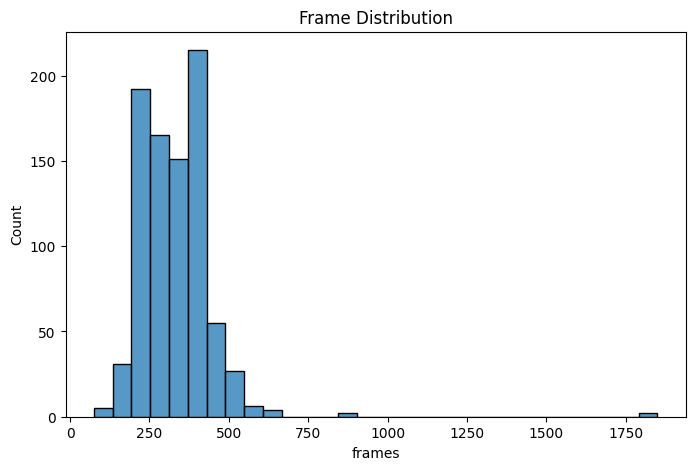

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["frames"], bins=30)
plt.title("Frame Distribution")
plt.show()

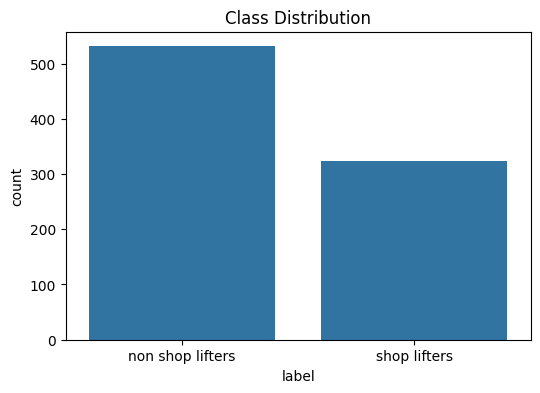

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()

In [7]:
def get_md5(file_path):

    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as f:

        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


hashes = {}
duplicates = []

for path in tqdm(df["path"]):

    file_hash = get_md5(path)

    if file_hash in hashes:
        duplicates.append(path)
    else:
        hashes[file_hash] = path

print("Duplicates:", len(duplicates))

100%|██████████| 855/855 [00:03<00:00, 220.56it/s]

Duplicates: 218


In [8]:
df = df[~df["path"].isin(duplicates)]

df = df.reset_index(drop=True)

print("Dataset after removing duplicates:", len(df))

Dataset after removing duplicates: 637


In [9]:
TARGET_FRAMES = 16
IMG_SIZE = 224

def load_video(path):

    cap = cv2.VideoCapture(path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0, total_frames-1, TARGET_FRAMES
    ).astype(int)

    frames = []

    for idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    frames = np.array(frames) / 255.0

    return frames

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df.label,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df.label
)

In [11]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

label_map = {c:i for i,c in enumerate(classes)}

In [12]:
class VideoDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        frames = load_video(row.path)

        processed = []

        for frame in frames:

            if self.transform:
                frame = self.transform(frame)

            processed.append(frame)

        video = torch.stack(processed)

        video = video.permute(1,0,2,3)

        label = label_map[row.label]

        return video.float(), label

In [13]:
train_dataset = VideoDataset(train_df, train_transform)
val_dataset = VideoDataset(val_df, val_transform)
test_dataset = VideoDataset(test_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=4)

In [14]:
labels = df.label.map(label_map).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(weights, dtype=torch.float)

In [15]:
model = x3d_m(pretrained=True)

model.blocks[-1].proj = nn.Linear(
    model.blocks[-1].proj.in_features,
    2
)

In [16]:
model = i3d_r50(pretrained=True)

model.blocks[-1].proj = nn.Linear(
    model.blocks[-1].proj.in_features,
    2
)

In [17]:
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

def train_model(model, train_loader, val_loader, class_weights, epochs=10):

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=2e-4,
        weight_decay=2e-4
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device)
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "precision": [],
        "recall": [],
        "f1": []
    }

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()

        running_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for videos, labels in progress_bar:

            videos = videos.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(videos)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            progress_bar.set_postfix(
                loss = running_loss/(progress_bar.n+1)
            )

        train_loss = running_loss / len(train_loader)

        history["train_loss"].append(train_loss)

        # ================= VALIDATION =================
        model.eval()

        val_running_loss = 0

        preds = []
        targets = []

        with torch.no_grad():

            for videos, labels in val_loader:

                videos = videos.to(device)
                labels = labels.to(device)

                outputs = model(videos)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                predicted = torch.argmax(outputs, dim=1)

                preds.extend(predicted.cpu().numpy())
                targets.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        history["val_loss"].append(val_loss)

        precision = precision_score(targets, preds)
        recall = recall_score(targets, preds)
        f1 = f1_score(targets, preds)

        history["precision"].append(precision)
        history["recall"].append(recall)
        history["f1"].append(f1)

        print("\n------------------------------")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Precision  : {precision:.4f}")
        print(f"Recall     : {recall:.4f}")
        print(f"F1 Score   : {f1:.4f}")
        print("------------------------------")

    return model, history

In [18]:
model_x3d, history_x3d = train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    epochs=5
)

Epoch 1/5: 100%|██████████| 112/112 [38:01<00:00, 20.37s/it, loss=0.427]



------------------------------
Epoch 1/5
Train Loss : 0.4273
Val Loss   : 0.6151
Precision  : 1.0000
Recall     : 0.5510
F1 Score   : 0.7105
------------------------------


Epoch 2/5: 100%|██████████| 112/112 [38:20<00:00, 20.54s/it, loss=0.258]



------------------------------
Epoch 2/5
Train Loss : 0.2575
Val Loss   : 0.6328
Precision  : 0.8889
Recall     : 0.9796
F1 Score   : 0.9320
------------------------------


Epoch 3/5: 100%|██████████| 112/112 [57:04<00:00, 30.58s/it, loss=0.143]



------------------------------
Epoch 3/5
Train Loss : 0.1432
Val Loss   : 0.6126
Precision  : 0.7538
Recall     : 1.0000
F1 Score   : 0.8596
------------------------------


Epoch 4/5: 100%|██████████| 112/112 [52:39<00:00, 28.21s/it, loss=0.141] 



------------------------------
Epoch 4/5
Train Loss : 0.1409
Val Loss   : 0.6271
Precision  : 0.7674
Recall     : 0.6735
F1 Score   : 0.7174
------------------------------


Epoch 5/5: 100%|██████████| 112/112 [48:13<00:00, 25.83s/it, loss=0.129]



------------------------------
Epoch 5/5
Train Loss : 0.1286
Val Loss   : 0.5957
Precision  : 0.5698
Recall     : 1.0000
F1 Score   : 0.7259
------------------------------


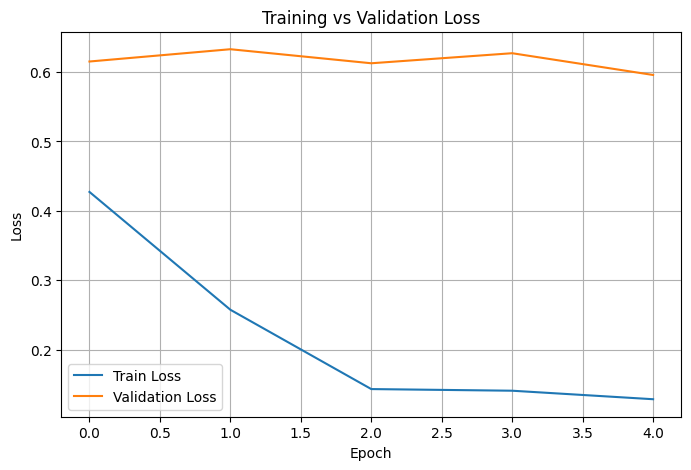

In [31]:
import matplotlib.pyplot as plt

def plot_losses(history):

    plt.figure(figsize=(8,5))

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.grid()
    plt.show()
plot_losses(history_x3d)

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

def test_model(model, test_loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for videos, labels in test_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            # support TimeSformer later
            if isinstance(outputs, dict):
                outputs = outputs["logits"]

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    precision = precision_score(targets, preds, zero_division=0)
    recall = recall_score(targets, preds, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)

    print("\n===== TEST RESULTS =====")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return preds, targets

In [26]:
preds, targets = test_model(model, test_loader)


===== TEST RESULTS =====
Precision : 0.5632
Recall    : 1.0000
F1 Score  : 0.7206


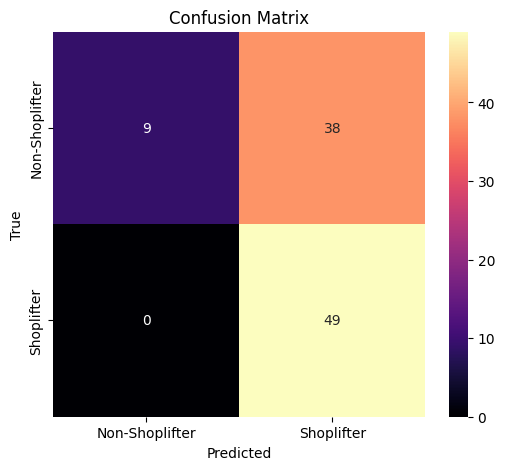

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(preds, targets):

    cm = confusion_matrix(targets, preds)

    class_names = ["Non-Shoplifter", "Shoplifter"]

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="magma",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()
plot_confusion_matrix(preds, targets)